In [1]:
library(tidyverse)

── Attaching packages ─────────────────────────────────────── tidyverse 1.2.1 ──
✔ ggplot2 3.1.0     ✔ purrr   0.2.5
✔ tibble  1.4.2     ✔ dplyr   0.7.8
✔ tidyr   0.8.2     ✔ stringr 1.3.1
✔ readr   1.1.1     ✔ forcats 0.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


In [2]:
DAT_DIR = "/data/flow/EQAPOL_normal"
RES_DIR = "/data/clinko/"

```
/data/flow/EQAPOL_normal/AMJ_5L_CMV_pp65.txt
/data/flow/EQAPOL_normal/AMJ_5L_Costim.txt
/data/flow/EQAPOL_normal/AMJ_5L_SEB.txt
```

In [17]:
system("cat /data/flow/EQAPOL_normal/markers.txt", intern = TRUE)

[1] "Scatter,FSC-H"           "Scatter,FSC-W"          
 [3] "Scatter,FSC-A"           "Basic,CD14 CD19 vAmine" 
 [5] "Basic,CD3 AmCyan"        "Basic,CD4 PerCP Cy55"   
 [7] "Basic,CD8 APC Cy7"       "Maturational,CD45RO ECD"
 [9] "Maturational,CD27 APC"   "Maturational,CD57 FITC" 
[11] "Functional,TNFa A700"    "Functional,IL 2 PE"     
[13] "Functional,IFNg PE Cy7"  "Functional,CD107 PE Cy5"

In [13]:
system("head -2 /data/flow/EQAPOL_normal/AMJ_5L_Costim.txt", intern = TRUE)

[1] "1.018520000000000000e+05 7.418068750000000000e+04 1.152870390625000000e+05 1.759094539995357263e+04 5.491982804719817068e+04 5.510407547093065659e+04 8.990052291904521553e+03 3.278475823798456986e+04 4.536509548637057742e+04 2.876466786316298021e+04 2.580220143132071098e+04 1.742527342681746813e+04 2.488605874349489022e+04 4.232201490729571378e+04"
[2] "4.746600000000000000e+04 1.137904843750000000e+05 8.241544531250000000e+04 3.779531456800597516e+04 4.694085147949823295e+04 4.298605160111440455e+03 3.073039705648520248e+04 6.054493787331152998e+04 4.071986162027496448e+03 8.641595290316012324e+03 2.040992783462718580e+04 3.288313297334415256e+04 3.450551827655782108e+04 5.211524941057188698e+04"

In [51]:
fpath = file.path(DAT_DIR, "markers.txt")
marker = read_csv(fpath, col_names = FALSE)

fpath = file.path(DAT_DIR, "B6901GFJ-08_Costim.txt")
dat_costim = read_delim(fpath, col_names = FALSE, delim = " ")
colnames(mat_costim) = marker$X2

fpath = file.path(DAT_DIR, "B6901GFJ-08_CMV_pp65.txt")
dat_cmv = read_delim(fpath, col_names = FALSE, delim = " ")
colnames(mat_cmv) = marker$X2

fpath = file.path(DAT_DIR, "B6901GFJ-08_SEB.txt")
dat_seb = read_delim(fpath, col_names = FALSE, delim = " ")
colnames(mat_seb) = marker$X2

Parsed with column specification:
cols(
  X1 = col_character(),
  X2 = col_character()
)
Parsed with column specification:
cols(
  X1 = col_double(),
  X2 = col_double(),
  X3 = col_double(),
  X4 = col_double(),
  X5 = col_double(),
  X6 = col_double(),
  X7 = col_double(),
  X8 = col_double(),
  X9 = col_double(),
  X10 = col_double(),
  X11 = col_double(),
  X12 = col_double(),
  X13 = col_double(),
  X14 = col_double()
)
Parsed with column specification:
cols(
  X1 = col_double(),
  X2 = col_double(),
  X3 = col_double(),
  X4 = col_double(),
  X5 = col_double(),
  X6 = col_double(),
  X7 = col_double(),
  X8 = col_double(),
  X9 = col_double(),
  X10 = col_double(),
  X11 = col_double(),
  X12 = col_double(),
  X13 = col_double(),
  X14 = col_double()
)
Parsed with column specification:
cols(
  X1 = col_double(),
  X2 = col_double(),
  X3 = col_double(),
  X4 = col_double(),
  X5 = col_double(),
  X6 = col_double(),
  X7 = col_double(),
  X8 = col_double(),
  X9 = col_double(),
  

In [43]:
head(dat_costim)

X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14
85260,89632.81,116609.09,38387.607,50245.73,40094.351,-7404.433,56457.187,23234.708,18888.052,51672.200,41595.47,32151.79,64193.47
83880,76323.14,97686.52,17854.954,18938.01,13645.215,16683.337,1579.537,6597.411,15157.431,20288.298,21395.18,22696.28,33672.56
77985,76107.66,90564.80,41827.465,36393.83,41013.530,47924.791,61757.223,18124.235,16972.745,67436.187,25973.66,22449.24,54844.28
66203,75817.44,76589.08,14368.130,55787.10,54091.083,28586.175,3188.824,45055.597,29874.413,30414.034,16565.56,23177.01,23474.96
178254,93635.41,254682.69,21989.705,62916.87,2420.449,72381.855,55605.566,52942.233,34336.541,37081.736,17086.72,29143.67,43167.10
86640,77111.73,101943.36,9917.962,53049.51,-4665.076,6533.778,36502.470,48637.029,8665.168,9366.829,16544.13,15131.77,12960.66


In [24]:
marker$X2

[1] "FSC-H"            "FSC-W"            "FSC-A"            "CD14 CD19 vAmine"
 [5] "CD3 AmCyan"       "CD4 PerCP Cy55"   "CD8 APC Cy7"      "CD45RO ECD"      
 [9] "CD27 APC"         "CD57 FITC"        "TNFa A700"        "IL 2 PE"         
[13] "IFNg PE Cy7"      "CD107 PE Cy5"

In [53]:
df1 = dat_costim[, c(6, 13)] #%>% select(`CD4 PerCP Cy55`)
df2 = dat_cmv[,    c(6, 13)]    #%>% select(`CD4 PerCP Cy55`)
df3 = dat_seb[,    c(6, 13)]    #%>% select(`CD4 PerCP Cy55`)

In [62]:
trt = c(rep("costim", nrow(df1)), rep("CMV", nrow(df2)), rep("SEB", nrow(df3)))
dat_combine = bind_rows(df1, df2, df3)
dat_combine$treatment = trt
dat_combine$treatment = factor(dat_combine$treatment, levels = c("costim", "CMV", "SEB"))
head(dat_combine)

X6,X13,treatment
40094.351,32151.79,costim
13645.215,22696.28,costim
41013.530,22449.24,costim
54091.083,23177.01,costim
2420.449,29143.67,costim
-4665.076,15131.77,costim


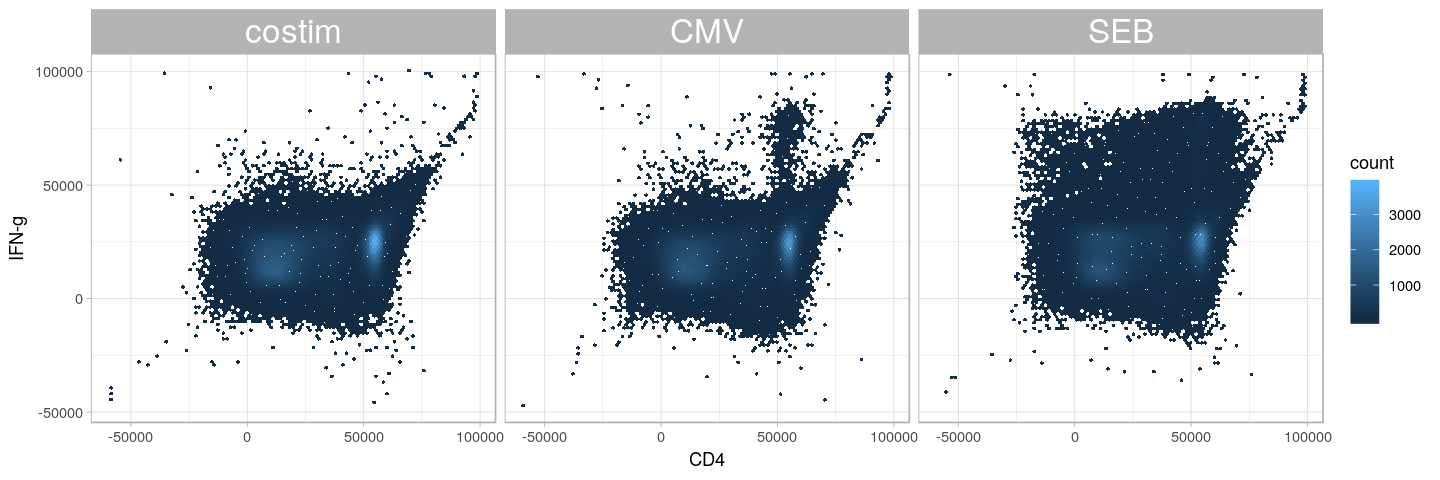

In [77]:
options(repr.plot.height = 4, repr.plot.width = 12)
gp = dat_combine %>% 
    ggplot(aes(x = X6, y = X13, group = treatment)) + 
    geom_hex(bins = 100) + 
    labs(x = "CD4", y = "IFN-g") +
    facet_wrap(~treatment) +
    theme_light() +
    theme(strip.text.x = element_text(size = 20))
ggsave(filename = "CD4_vs_IFNg.png", plot = gp, dpi = 300, width = 12, height = 4)
print(gp)

In [ ]:
ggplot(dat_)